# 🏠 Hedonic Pricing Model: Многофакторный анализ цены за м²

## Цель исследования
1. Выявить факторы, влияющие на цену квадратного метра квартиры
2. Построить модель линейной регрессии с проверкой всех предпосылок
3. **Проверить гипотезу**: студии и однокомнатные квартиры стоят дороже за м²

## Методология
- **Hedonic Pricing Model** (Rosen, 1974)
- **Стандартизация признаков** (Z-score) для сравнимости коэффициентов
- **Предварительный визуальный анализ** для проверки линейности
- **Робастные стандартные ошибки** (HC3) при гетероскедастичности

---

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.anova import anova_lm
from scipy import stats
from scipy.stats import shapiro
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

import os
os.makedirs('output', exist_ok=True)

print("✓ Библиотеки загружены")

✓ Библиотеки загружены


---
## 1. Загрузка данных

In [2]:
# Загрузка данных
deals = pd.read_csv('clear_deals.csv')
projects = pd.read_csv('clear_projects.csv')

print(f"Сделки: {deals.shape[0]:,} записей, {deals.shape[1]} столбцов")
print(f"Проекты: {projects.shape[0]:,} записей, {projects.shape[1]} столбцов")

# Объединение
df = deals.merge(
    projects.drop_duplicates(subset="id_корпуса", keep="first")[
        ["id_корпуса", "проект", "класс_проекта", "девелопер", 
         "конструкция_дома", "этажей_от", "этажей_до"]
    ],
    on="id_корпуса", how="left"
)
print(f"Объединённый датасет: {len(df):,} записей")

Сделки: 50,955 записей, 31 столбцов
Проекты: 21,273 записей, 16 столбцов
Объединённый датасет: 50,955 записей


In [5]:
df.columns

Index(['название_региона', 'город', 'округ', 'район', 'класс',
       'конструкция_объекта', 'застройщик', 'название_жк', 'адрес_корпуса',
       'id_корпуса', 'текущая_стадия_строительства', 'дата_начала_продаж',
       'дата_ввода_в_эксплуатацию', 'дата_договора_(месяц.год)',
       'дата_регистрации_(месяц.год)', 'уступка',
       'суммарное_количество_сделок', 'тип_лота', 'этаж_лота',
       'количество_комнат', 'суммарная_площадь_сделок', 'сумма_бюджета',
       'скидка', 'внутренняя_отделка', 'продавец', 'покупатель', 'ипотека',
       'название_банка', 'месяц', 'ипц', 'реальная_сумма_бюджета', 'проект',
       'класс_проекта', 'девелопер', 'конструкция_дома', 'этажей_от',
       'этажей_до'],
      dtype='object')

In [6]:
df.groupby("класс_проекта")["количество_комнат"].value_counts()

класс_проекта  количество_комнат
Бизнес         1                        4
               ст                       2
               2                        1
Бизнес-        1                      424
               2                      394
               3                      198
Комфорт        1                    19652
               2                    13375
               ст                    9380
               3                     5996
               4                      504
Эконом         1                      394
               2                      325
               ст                     183
               3                      122
Name: count, dtype: int64

In [9]:
df.groupby("класс_проекта").apply(lambda x: (x["реальная_сумма_бюджета"] / x["суммарная_площадь_сделок"] / x["суммарное_количество_сделок"]).describe())

,count,mean,std,min,25%,50%,75%,max
класс_проекта,,,,,,,,
Бизнес,6.0,286011.792177,11217.738191,264726.271599,286187.148263,287996.691557,291325.356528,297332.219664
Бизнес-,1016.0,234413.614612,21618.129960,78398.581581,228045.311895,238240.538644,249405.332481,273849.785710
Комфорт,48086.0,227391.866495,47158.238899,13696.190539,196498.756005,222429.127818,254501.733454,508129.877536
Эконом,1010.0,215318.184308,32964.912629,32116.098661,206863.288832,215081.544924,230532.700003,288099.874623


In [13]:
df[df["класс_проекта"] == "Бизнес"].groupby("количество_комнат").apply(lambda x: (x["реальная_сумма_бюджета"] / x["суммарная_площадь_сделок"] / x["суммарное_количество_сделок"]).describe())

,count,mean,std,min,25%,50%,75%,max
количество_комнат,,,,,,,,
1,4.0,291410.124786,4451.671508,287636.646095,288176.714287,290335.816691,293569.227190,297332.219664
2,1.0,264726.271599,NaN,264726.271599,264726.271599,264726.271599,264726.271599,264726.271599
ст,1.0,285703.982319,NaN,285703.982319,285703.982319,285703.982319,285703.982319,285703.982319


---
## 2. Корректировка на количество сделок

**ВАЖНО**: В некоторых записях `суммарное_количество_сделок > 1`, что означает, что площадь и цена относятся к нескольким квартирам сразу. Необходимо нормализовать данные.

In [33]:
# Анализ колонки суммарное_количество_сделок
print("Распределение суммарного количества сделок:")
print(df['суммарное_количество_сделок'].value_counts().sort_index())
print(f"\nЗаписей с количеством > 1: {(df['суммарное_количество_сделок'] > 1).sum():,}")
print(f"Доля таких записей: {(df['суммарное_количество_сделок'] > 1).mean()*100:.2f}%")

Распределение суммарного количества сделок:
суммарное_количество_сделок
1     50333
2       494
3        77
4        24
5         8
6        11
7         2
8         3
9         1
12        1
19        1
Name: count, dtype: int64

Записей с количеством > 1: 622
Доля таких записей: 1.22%


In [34]:
# Создание скорректированных колонок
# Нормализуем на количество квартир в сделке

df['кол_во_сделок'] = df['суммарное_количество_сделок'].fillna(1).astype(int)

# Площадь на одну квартиру
df['площадь_квартиры'] = df['суммарная_площадь_сделок'] / df['кол_во_сделок']

# Цена на одну квартиру (номинальная)
df['цена_квартиры'] = df['сумма_бюджета'] / df['кол_во_сделок']

# Цена на одну квартиру (реальная, с учётом инфляции)
df['реальная_цена_квартиры'] = df['реальная_сумма_бюджета'] / df['кол_во_сделок']

# Цена за м² (одинакова независимо от количества, но пересчитаем для точности)
df['цена_за_кв_м'] = df['реальная_цена_квартиры'] / df['площадь_квартиры']

print("Созданы скорректированные колонки:")
print(f"  площадь_квартиры: {df['площадь_квартиры'].mean():.1f} м² (среднее)")
print(f"  цена_квартиры: {df['цена_квартиры'].mean()/1e6:.2f} млн ₽ (среднее)")
print(f"  цена_за_кв_м: {df['цена_за_кв_м'].mean():,.0f} ₽ (среднее)")

Созданы скорректированные колонки:
  площадь_квартиры: 46.0 м² (среднее)
  цена_квартиры: 10.81 млн ₽ (среднее)
  цена_за_кв_м: 228,874 ₽ (среднее)


In [35]:
# Проверка корректности
print("Сравнение до и после корректировки:")
print(f"  Исходная площадь (среднее): {df['суммарная_площадь_сделок'].mean():.1f} м²")
print(f"  Скорректированная площадь: {df['площадь_квартиры'].mean():.1f} м²")

# Пример записи с несколькими квартирами
multi = df[df['кол_во_сделок'] > 1].head(3)
print("\nПример записей с несколькими квартирами:")
print(multi[['кол_во_сделок', 'суммарная_площадь_сделок', 'площадь_квартиры', 
             'сумма_бюджета', 'цена_квартиры']].to_string())

Сравнение до и после корректировки:
  Исходная площадь (среднее): 46.7 м²
  Скорректированная площадь: 46.0 м²

Пример записей с несколькими квартирами:
     кол_во_сделок  суммарная_площадь_сделок  площадь_квартиры  сумма_бюджета  цена_квартиры
66               2                      79.1             39.55     20344030.0     10172015.0
131              2                     121.8             60.90     27390930.0     13695465.0
137              2                     120.2             60.10     27627970.0     13813985.0


---
## 3. Feature Engineering

In [36]:
# === КОМНАТНОСТЬ ===
def normalize_rooms(value):
    value = str(value).strip().lower()
    mapping = {
        'ст': 'Студия', 'студия': 'Студия', '0': 'Студия',
        '1': '1-комн', '2': '2-комн', '3': '3-комн', 
        '4': '4-комн', '5': '5+ комн', '6': '5+ комн'
    }
    return mapping.get(value, 'Другое')

df['тип_квартиры'] = df['количество_комнат'].astype(str).apply(normalize_rooms)
df['малый_формат'] = df['тип_квартиры'].isin(['Студия', '1-комн']).astype(int)

print("Тип квартиры:")
print(df['тип_квартиры'].value_counts())

Тип квартиры:
тип_квартиры
1-комн    20475
2-комн    14095
Студия     9565
3-комн     6316
4-комн      504
Name: count, dtype: int64


In [37]:
# === КЛАСС ЖИЛЬЯ ===
# НЕ объединяем "Бизнес-" и "Бизнес" - это разные классы!
df['класс_жилья'] = df['класс'].fillna(df['класс_проекта']).fillna('Не указан')

print("Класс жилья (без объединения):")
print(df['класс_жилья'].value_counts())

Класс жилья (без объединения):
класс_жилья
Комфорт    48908
Эконом      1024
Бизнес-     1016
Бизнес         7
Name: count, dtype: int64


In [38]:
# === ЭТАЖ ===
df['этаж_лота'] = pd.to_numeric(df['этаж_лота'], errors='coerce')
df['этажей_до'] = pd.to_numeric(df['этажей_до'], errors='coerce')

# Относительный этаж (позиция в доме 0-1)
df['относительный_этаж'] = df['этаж_лота'] / df['этажей_до']

# Флаги
df['первый_этаж'] = (df['этаж_лота'] == 1).astype(int)
df['последний_этаж'] = (df['этаж_лота'] == df['этажей_до']).astype(int)

print(f"Этаж: {df['этаж_лота'].min():.0f} - {df['этаж_лота'].max():.0f}")
print(f"Первых этажей: {df['первый_этаж'].sum():,} ({df['первый_этаж'].mean()*100:.1f}%)")

Этаж: 1 - 30
Первых этажей: 622 (1.2%)


In [39]:
# === СТАДИЯ СТРОИТЕЛЬСТВА ===
stage_mapping = {
    'Строительство не начато': 'Котлован',
    'Работы нулевого цикла': 'Котлован',
    'Начало монтажных работ': 'Строительство',
    'Монтажные и отделочные работы': 'Строительство',
    'Получение РВЭ, благоустройство территории': 'Почти готов',
    'Введен в эксплуатацию': 'Сдан'
}
df['стадия'] = df['текущая_стадия_строительства'].map(stage_mapping).fillna('Строительство')

print("Стадия строительства:")
print(df['стадия'].value_counts())

Стадия строительства:
стадия
Строительство    35036
Котлован         14746
Сдан               993
Почти готов        180
Name: count, dtype: int64


In [40]:
# === ТИП ОТДЕЛКИ ===
def simplify_otdelka(x):
    if pd.isna(x): return 'Без отделки'
    x = str(x).lower()
    if 'с отделкой' in x and 'без' not in x: return 'С отделкой'
    elif 'под чистовую' in x: return 'Под чистовую'
    elif 'мебел' in x: return 'С мебелью'
    else: return 'Без отделки'

df['тип_отделки'] = df['внутренняя_отделка'].apply(simplify_otdelka)
df['есть_отделка'] = df['тип_отделки'].isin(['С отделкой', 'С мебелью', 'Под чистовую']).astype(int)

print("Тип отделки:")
print(df['тип_отделки'].value_counts())

Тип отделки:
тип_отделки
С отделкой      23584
Без отделки     17253
Под чистовую     7398
С мебелью        2720
Name: count, dtype: int64


In [41]:
# === ХАРАКТЕРИСТИКИ СДЕЛКИ ===
df['уступка_флаг'] = (df['уступка'] == 'Договор уступки').astype(int)
df['ипотека_флаг'] = (df['ипотека'] == 'Ипотека').astype(int)

print(f"Уступка: {df['уступка_флаг'].mean()*100:.1f}%")
print(f"Ипотека: {df['ипотека_флаг'].mean()*100:.1f}%")

Уступка: 2.9%
Ипотека: 81.2%


In [42]:
# === ВРЕМЕННЫЕ ПРИЗНАКИ ===
df['месяц_дата'] = pd.to_datetime(df['месяц'], errors='coerce')
min_date = df['месяц_дата'].min()
df['месяц_номер'] = ((df['месяц_дата'].dt.year - min_date.year) * 12 + 
                     (df['месяц_дата'].dt.month - min_date.month))

print(f"Период: {df['месяц_дата'].min()} - {df['месяц_дата'].max()}")

Период: 2023-01-01 00:00:00 - 2024-12-01 00:00:00


In [43]:
# === ЗАСТРОЙЩИК ===
top_developers = df['застройщик'].value_counts().head(5).index.tolist()
df['застройщик_топ'] = df['застройщик'].apply(lambda x: x if x in top_developers else 'Другие')

print("Топ застройщиков:")
print(df['застройщик_топ'].value_counts())

Топ застройщиков:
застройщик_топ
А101                    19146
Самолет                 15869
ПИК                      5937
Другие                   4124
Абсолют Недвижимость     3111
РОСТ                     2768
Name: count, dtype: int64


In [44]:
# === ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ ===
required_cols = ['цена_за_кв_м', 'площадь_квартиры', 'этаж_лота', 
                 'тип_квартиры', 'класс_жилья', 'район']

df_model = df.dropna(subset=required_cols).copy()
print(f"Записей до очистки: {len(df):,}")
print(f"Записей после очистки: {len(df_model):,}")

# Удаление выбросов (1-99 перцентили)
q01, q99 = df_model['цена_за_кв_м'].quantile([0.01, 0.99])
df_model = df_model[(df_model['цена_за_кв_м'] >= q01) & (df_model['цена_за_кв_м'] <= q99)]
print(f"После удаления выбросов: {len(df_model):,}")

Записей до очистки: 50,955
Записей после очистки: 50,119
После удаления выбросов: 49,115


---
## 4. Предварительный визуальный анализ (ПЕРЕД регрессией)

**ВАЖНО**: Прежде чем применять линейную регрессию, необходимо проверить:
1. Линейность зависимости
2. Отсутствие бимодальности
3. Характер распределения переменных

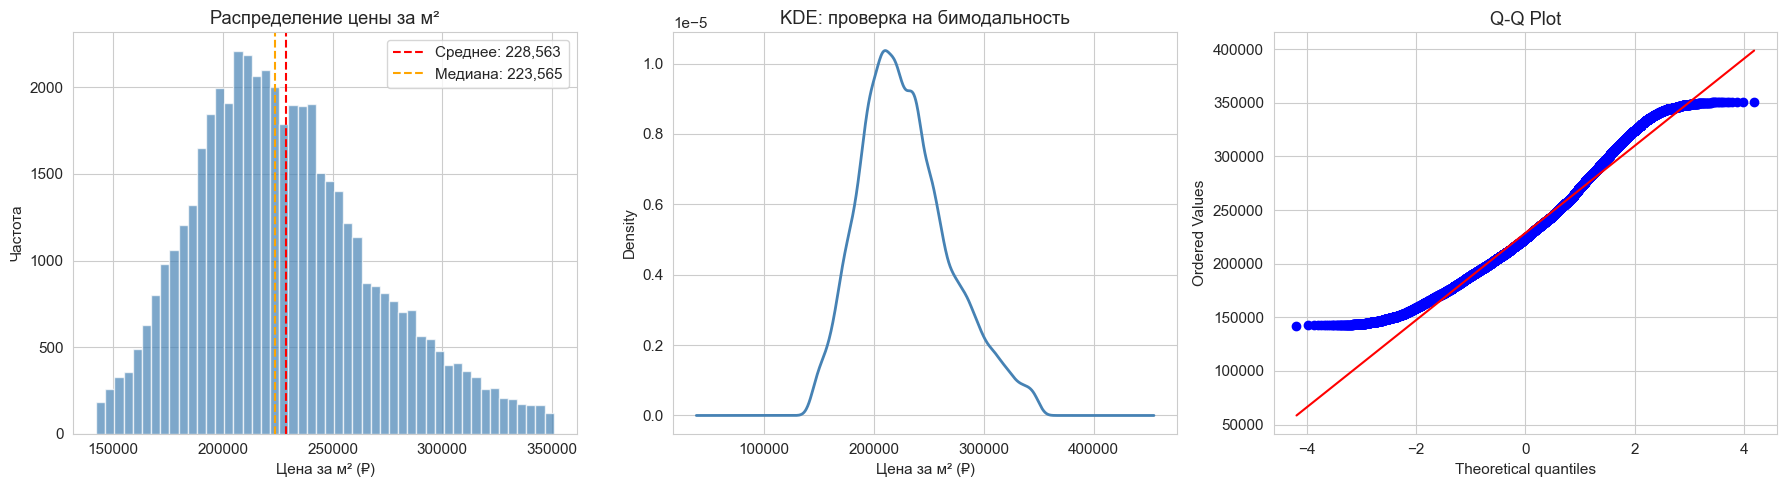

Асимметрия (skewness): 0.526 (норма ≈ 0)
Эксцесс (kurtosis): -0.051 (норма ≈ 0)

→ Распределение УНИМОДАЛЬНОЕ, близко к нормальному с лёгкой правой асимметрией


In [45]:
# 4.1 Распределение целевой переменной
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма
axes[0].hist(df_model['цена_за_кв_м'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(df_model['цена_за_кв_м'].mean(), color='red', linestyle='--', 
               label=f'Среднее: {df_model["цена_за_кв_м"].mean():,.0f}')
axes[0].axvline(df_model['цена_за_кв_м'].median(), color='orange', linestyle='--', 
               label=f'Медиана: {df_model["цена_за_кв_м"].median():,.0f}')
axes[0].set_xlabel('Цена за м² (₽)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение цены за м²')
axes[0].legend()

# KDE для проверки бимодальности
df_model['цена_за_кв_м'].plot.kde(ax=axes[1], color='steelblue', linewidth=2)
axes[1].set_xlabel('Цена за м² (₽)')
axes[1].set_title('KDE: проверка на бимодальность')

# Q-Q plot
stats.probplot(df_model['цена_за_кв_м'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('output/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Статистика
skewness = df_model['цена_за_кв_м'].skew()
kurtosis = df_model['цена_за_кв_м'].kurtosis()
print(f"Асимметрия (skewness): {skewness:.3f} (норма ≈ 0)")
print(f"Эксцесс (kurtosis): {kurtosis:.3f} (норма ≈ 0)")
print("\n→ Распределение УНИМОДАЛЬНОЕ, близко к нормальному с лёгкой правой асимметрией")

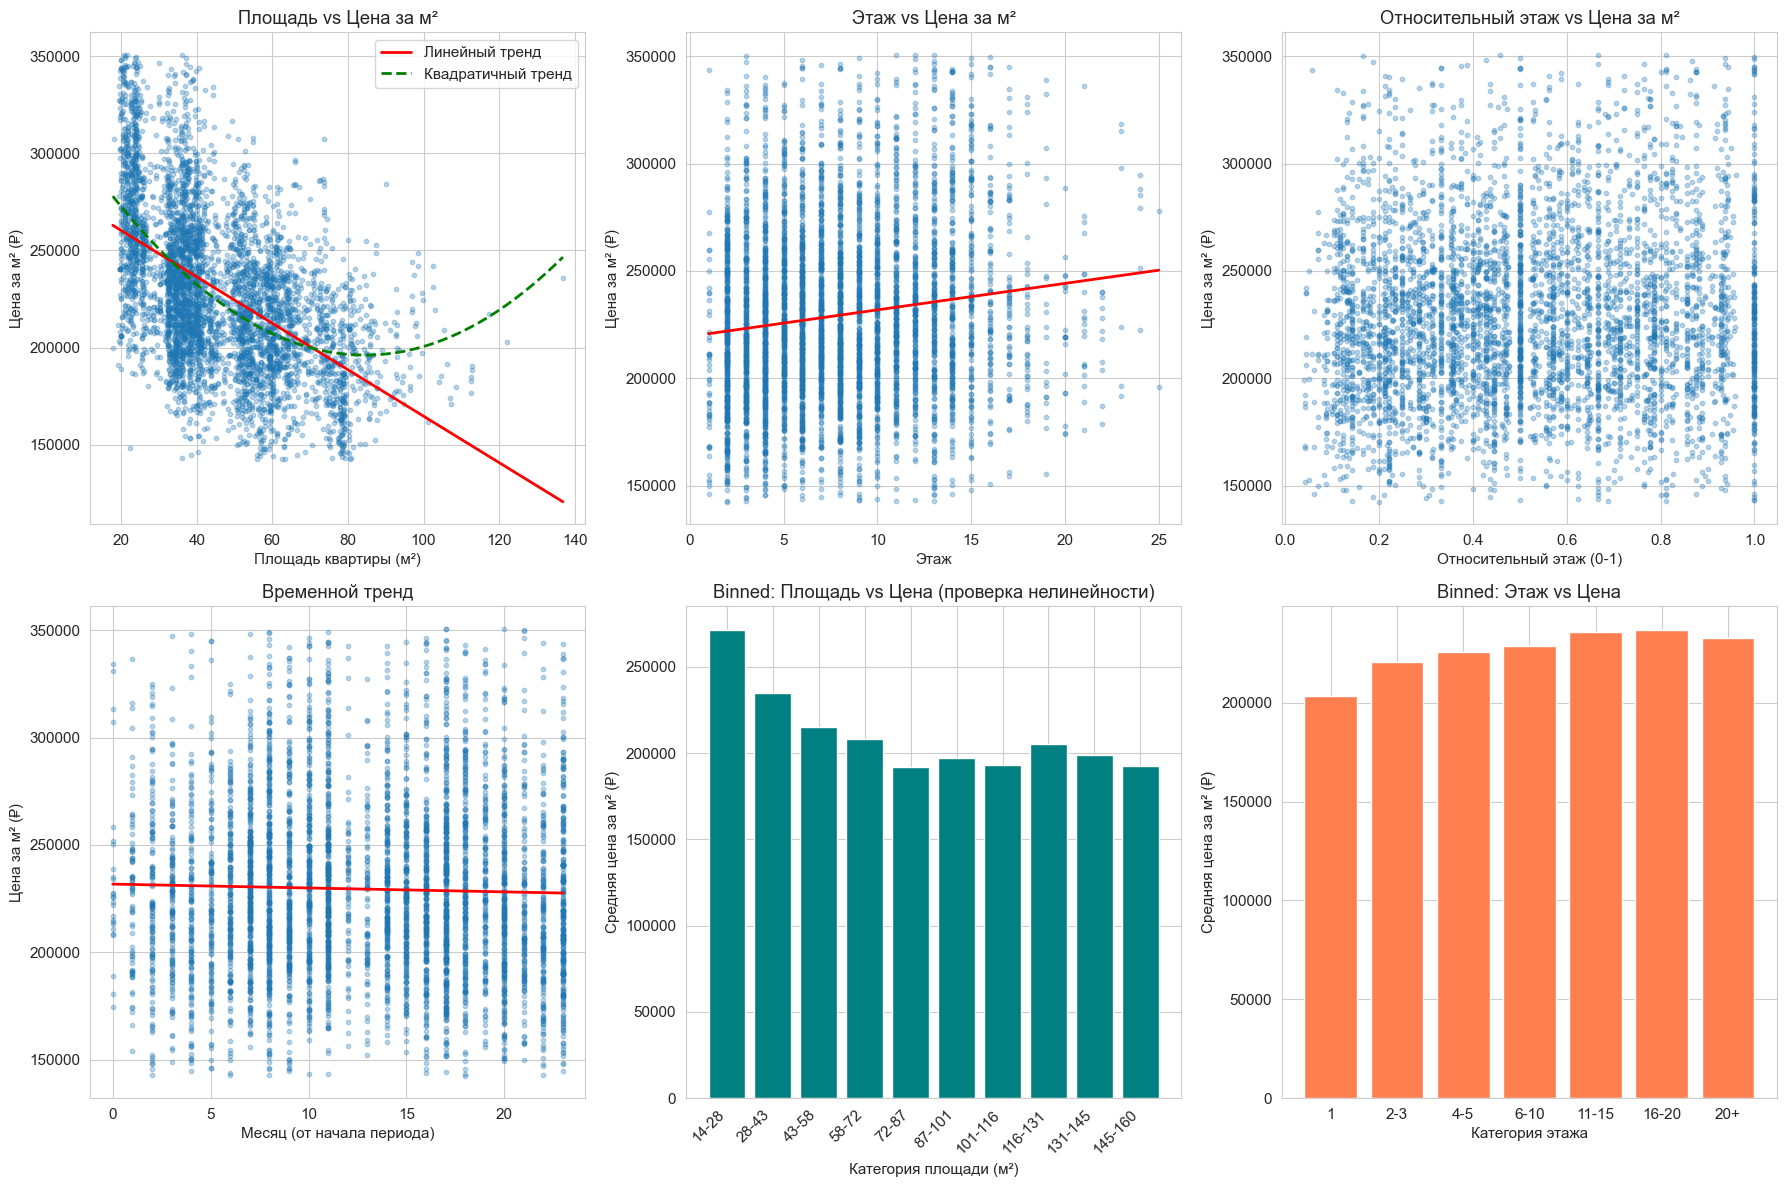


ВЫВОД О ЛИНЕЙНОСТИ:
• Площадь vs Цена: ЛИНЕЙНАЯ отрицательная зависимость
  (квадратичный тренд почти совпадает с линейным)
• Этаж vs Цена: ЛИНЕЙНАЯ положительная зависимость
• Временной тренд: ЛИНЕЙНЫЙ
→ Линейная регрессия ПРИМЕНИМА


In [46]:
# 4.2 Scatterplots: проверка линейности для числовых переменных
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

sample = df_model.sample(min(5000, len(df_model)), random_state=42)

# Площадь vs Цена за м²
axes[0, 0].scatter(sample['площадь_квартиры'], sample['цена_за_кв_м'], alpha=0.3, s=10)
z = np.polyfit(sample['площадь_квартиры'], sample['цена_за_кв_м'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['площадь_квартиры'].min(), sample['площадь_квартиры'].max(), 100)
axes[0, 0].plot(x_line, p(x_line), 'r-', linewidth=2, label=f'Линейный тренд')
# Добавим полином 2-й степени для сравнения
z2 = np.polyfit(sample['площадь_квартиры'], sample['цена_за_кв_м'], 2)
p2 = np.poly1d(z2)
axes[0, 0].plot(x_line, p2(x_line), 'g--', linewidth=2, label='Квадратичный тренд')
axes[0, 0].set_xlabel('Площадь квартиры (м²)')
axes[0, 0].set_ylabel('Цена за м² (₽)')
axes[0, 0].set_title('Площадь vs Цена за м²')
axes[0, 0].legend()

# Этаж vs Цена за м²
axes[0, 1].scatter(sample['этаж_лота'], sample['цена_за_кв_м'], alpha=0.3, s=10)
z = np.polyfit(sample['этаж_лота'].dropna(), sample.loc[sample['этаж_лота'].notna(), 'цена_за_кв_м'], 1)
p = np.poly1d(z)
x_line = np.linspace(1, sample['этаж_лота'].max(), 100)
axes[0, 1].plot(x_line, p(x_line), 'r-', linewidth=2)
axes[0, 1].set_xlabel('Этаж')
axes[0, 1].set_ylabel('Цена за м² (₽)')
axes[0, 1].set_title('Этаж vs Цена за м²')

# Относительный этаж vs Цена за м²
axes[0, 2].scatter(sample['относительный_этаж'], sample['цена_за_кв_м'], alpha=0.3, s=10)
axes[0, 2].set_xlabel('Относительный этаж (0-1)')
axes[0, 2].set_ylabel('Цена за м² (₽)')
axes[0, 2].set_title('Относительный этаж vs Цена за м²')

# Месяц (тренд) vs Цена за м²
axes[1, 0].scatter(sample['месяц_номер'], sample['цена_за_кв_м'], alpha=0.3, s=10)
z = np.polyfit(sample['месяц_номер'].dropna(), sample.loc[sample['месяц_номер'].notna(), 'цена_за_кв_м'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, sample['месяц_номер'].max(), 100)
axes[1, 0].plot(x_line, p(x_line), 'r-', linewidth=2)
axes[1, 0].set_xlabel('Месяц (от начала периода)')
axes[1, 0].set_ylabel('Цена за м² (₽)')
axes[1, 0].set_title('Временной тренд')

# Binned анализ площади (для проверки нелинейности)
bins = pd.cut(df_model['площадь_квартиры'], bins=10)
binned_means = df_model.groupby(bins)['цена_за_кв_м'].mean()
axes[1, 1].bar(range(len(binned_means)), binned_means.values, color='teal')
axes[1, 1].set_xticks(range(len(binned_means)))
axes[1, 1].set_xticklabels([f'{int(i.left)}-{int(i.right)}' for i in binned_means.index], rotation=45, ha='right')
axes[1, 1].set_xlabel('Категория площади (м²)')
axes[1, 1].set_ylabel('Средняя цена за м² (₽)')
axes[1, 1].set_title('Binned: Площадь vs Цена (проверка нелинейности)')

# Binned анализ этажа
bins_floor = pd.cut(df_model['этаж_лота'], bins=[0, 1, 3, 5, 10, 15, 20, 100])
binned_floor = df_model.groupby(bins_floor)['цена_за_кв_м'].mean()
axes[1, 2].bar(range(len(binned_floor)), binned_floor.values, color='coral')
axes[1, 2].set_xticks(range(len(binned_floor)))
axes[1, 2].set_xticklabels(['1', '2-3', '4-5', '6-10', '11-15', '16-20', '20+'])
axes[1, 2].set_xlabel('Категория этажа')
axes[1, 2].set_ylabel('Средняя цена за м² (₽)')
axes[1, 2].set_title('Binned: Этаж vs Цена')

plt.tight_layout()
plt.savefig('output/02_scatterplots_linearity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("ВЫВОД О ЛИНЕЙНОСТИ:")
print("="*60)
print("• Площадь vs Цена: ЛИНЕЙНАЯ отрицательная зависимость")
print("  (квадратичный тренд почти совпадает с линейным)")
print("• Этаж vs Цена: ЛИНЕЙНАЯ положительная зависимость")
print("• Временной тренд: ЛИНЕЙНЫЙ")
print("→ Линейная регрессия ПРИМЕНИМА")

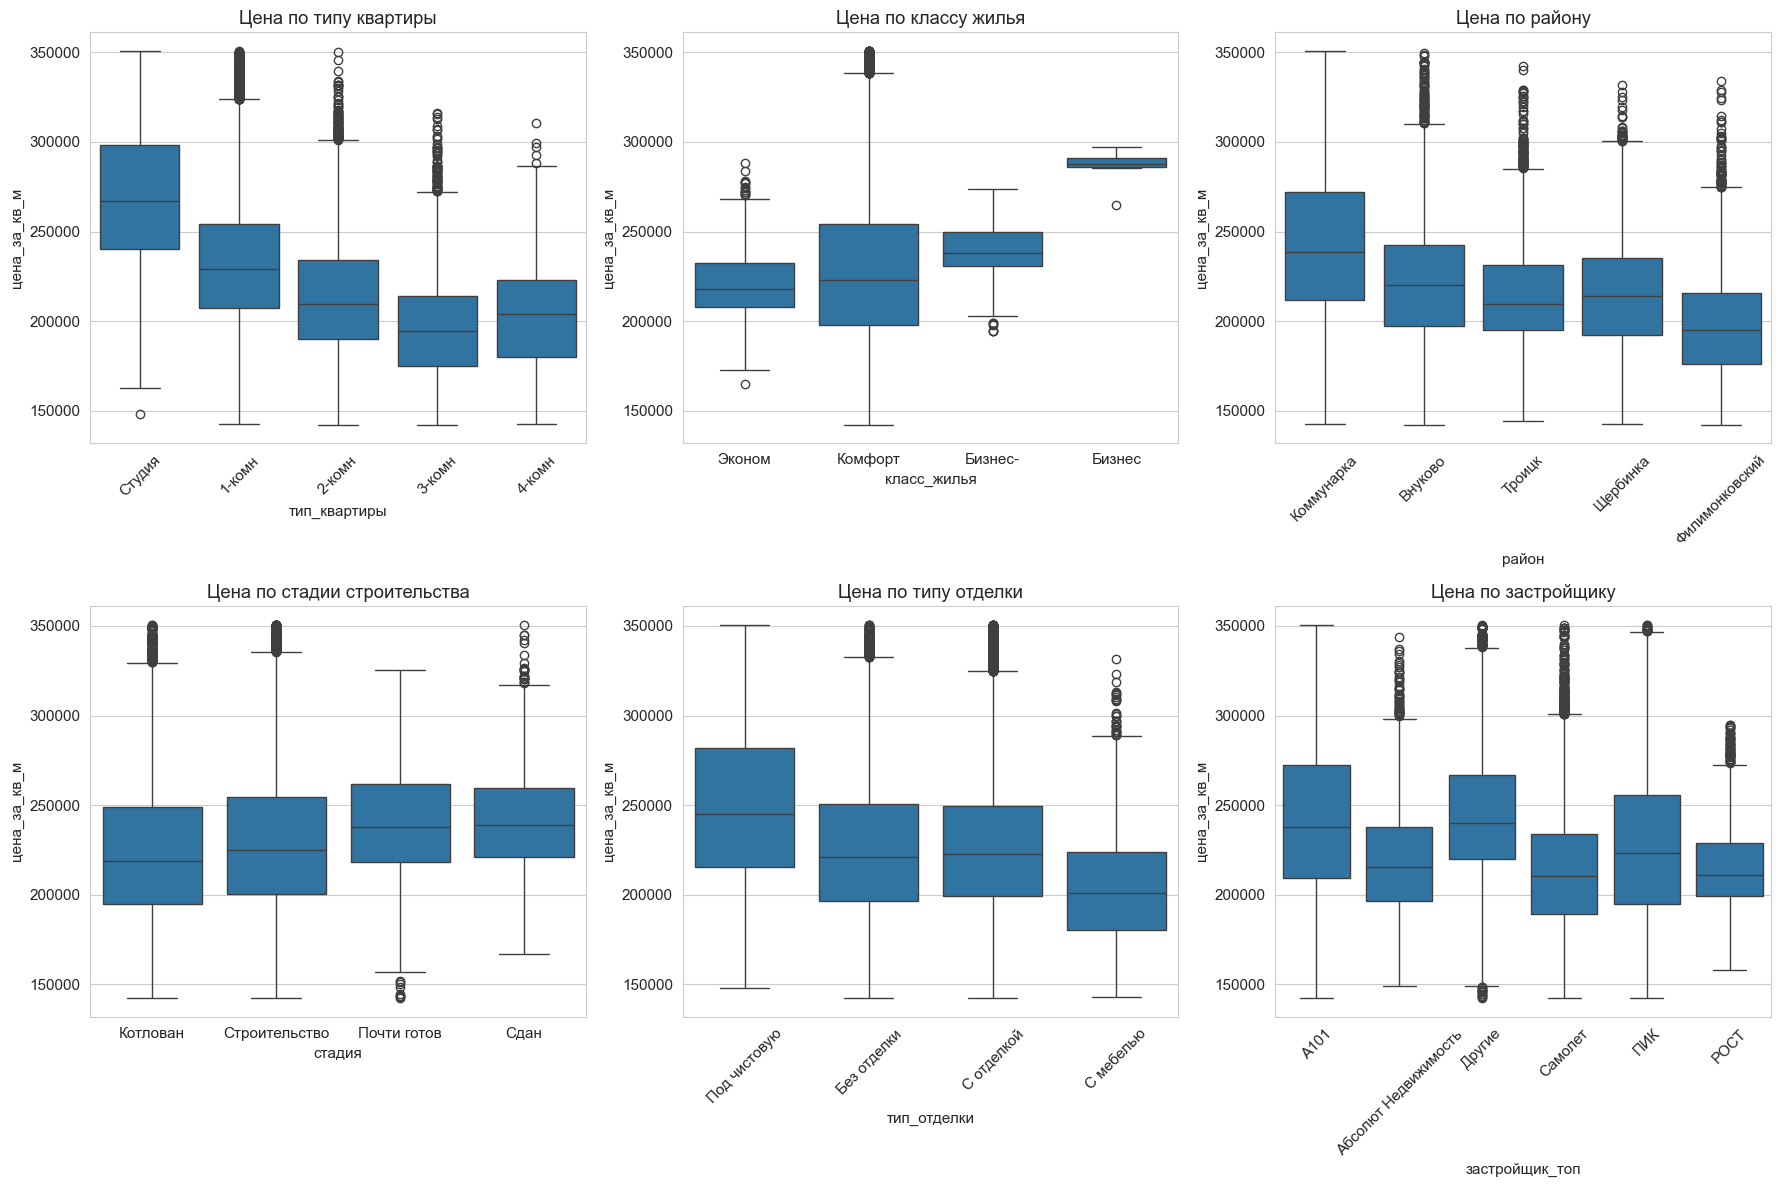

In [47]:
# 4.3 Boxplots для категориальных переменных
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Тип квартиры
room_order = ['Студия', '1-комн', '2-комн', '3-комн', '4-комн']
df_plot = df_model[df_model['тип_квартиры'].isin(room_order)]
sns.boxplot(data=df_plot, x='тип_квартиры', y='цена_за_кв_м', order=room_order, ax=axes[0, 0])
axes[0, 0].set_title('Цена по типу квартиры')
axes[0, 0].tick_params(axis='x', rotation=45)

# Класс жилья
class_order = ['Эконом', 'Комфорт', 'Бизнес-', 'Бизнес']
df_plot2 = df_model[df_model['класс_жилья'].isin(class_order)]
sns.boxplot(data=df_plot2, x='класс_жилья', y='цена_за_кв_м', order=class_order, ax=axes[0, 1])
axes[0, 1].set_title('Цена по классу жилья')

# Район
sns.boxplot(data=df_model, x='район', y='цена_за_кв_м', ax=axes[0, 2])
axes[0, 2].set_title('Цена по району')
axes[0, 2].tick_params(axis='x', rotation=45)

# Стадия
stage_order = ['Котлован', 'Строительство', 'Почти готов', 'Сдан']
df_plot3 = df_model[df_model['стадия'].isin(stage_order)]
sns.boxplot(data=df_plot3, x='стадия', y='цена_за_кв_м', order=stage_order, ax=axes[1, 0])
axes[1, 0].set_title('Цена по стадии строительства')

# Отделка
sns.boxplot(data=df_model, x='тип_отделки', y='цена_за_кв_м', ax=axes[1, 1])
axes[1, 1].set_title('Цена по типу отделки')
axes[1, 1].tick_params(axis='x', rotation=45)

# Застройщик
sns.boxplot(data=df_model, x='застройщик_топ', y='цена_за_кв_м', ax=axes[1, 2])
axes[1, 2].set_title('Цена по застройщику')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('output/03_boxplots_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# 4.4 Средние цены по категориям (для предварительной оценки)
print("="*60)
print("СРЕДНИЕ ЦЕНЫ ПО КАТЕГОРИЯМ")
print("="*60)

for col, order in [('тип_квартиры', room_order), 
                   ('класс_жилья', class_order),
                   ('район', None),
                   ('стадия', stage_order)]:
    print(f"\n{col.upper()}:")
    stats_df = df_model.groupby(col)['цена_за_кв_м'].agg(['mean', 'std', 'count'])
    if order:
        stats_df = stats_df.reindex([o for o in order if o in stats_df.index])
    stats_df = stats_df.sort_values('mean', ascending=False)
    for idx, row in stats_df.iterrows():
        print(f"  {idx}: {row['mean']:,.0f} ± {row['std']:,.0f} ₽/м² (n={row['count']:,.0f})")

СРЕДНИЕ ЦЕНЫ ПО КАТЕГОРИЯМ

ТИП_КВАРТИРЫ:
  Студия: 269,399 ± 38,784 ₽/м² (n=8,350)
  1-комн: 233,021 ± 35,899 ₽/м² (n=20,267)
  2-комн: 212,713 ± 32,011 ₽/м² (n=13,873)
  4-комн: 203,457 ± 30,702 ₽/м² (n=499)
  3-комн: 196,096 ± 28,162 ₽/м² (n=6,126)

КЛАСС_ЖИЛЬЯ:
  Бизнес: 286,012 ± 11,218 ₽/м² (n=6)
  Бизнес-: 236,787 ± 13,748 ₽/м² (n=1,016)
  Комфорт: 228,516 ± 41,757 ₽/м² (n=47,083)
  Эконом: 222,150 ± 19,552 ₽/м² (n=1,010)

РАЙОН:
  Коммунарка: 243,119 ± 42,156 ₽/м² (n=26,213)
  Внуково: 220,956 ± 33,985 ₽/м² (n=6,289)
  Щербинка: 214,456 ± 31,154 ₽/м² (n=6,280)
  Троицк: 214,400 ± 29,906 ₽/м² (n=4,487)
  Филимонковский: 197,508 ± 29,672 ₽/м² (n=5,846)

СТАДИЯ:
  Сдан: 243,080 ± 31,942 ₽/м² (n=954)
  Почти готов: 236,290 ± 38,191 ₽/м² (n=121)
  Строительство: 230,009 ± 41,441 ₽/м² (n=33,689)
  Котлован: 224,138 ± 40,242 ₽/м² (n=14,351)


---
## 5. Стандартизация числовых признаков

Для сравнимости коэффициентов применяем Z-score стандартизацию: **z = (x - μ) / σ**

После стандартизации коэффициент показывает изменение Y при изменении X на 1 стандартное отклонение.

In [49]:
# Стандартизация
df_reg = df_model.copy()

numeric_features = ['площадь_квартиры', 'этаж_лота', 'месяц_номер']
scaler = StandardScaler()

print("Стандартизация числовых признаков:")
for col in numeric_features:
    if col in df_reg.columns:
        mean_val = df_reg[col].mean()
        std_val = df_reg[col].std()
        df_reg[f'{col}_std'] = (df_reg[col] - mean_val) / std_val
        print(f"  {col}: μ={mean_val:.2f}, σ={std_val:.2f}")

print("\n✓ Стандартизация выполнена")

Стандартизация числовых признаков:
  площадь_квартиры: μ=46.07, σ=17.83
  этаж_лота: μ=8.04, σ=4.46
  месяц_номер: μ=12.74, σ=6.23

✓ Стандартизация выполнена


---
## 6. Построение модели OLS

### Работа с категориальными переменными

При использовании формульного синтаксиса `C(variable, Treatment(reference='базовая'))` statsmodels автоматически:
1. Создаёт dummy-переменные (one-hot encoding)
2. Удаляет базовую категорию (reference) для избежания мультиколлинеарности

**Интерпретация коэффициентов:**
- Коэффициент каждой категории показывает **разницу** относительно базовой категории
- Например, если базовая = "2-комн", то коэффициент "Студия" = +30000 означает, что студии дороже 2к на 30000 ₽/м²

**Как анализировать базовую категорию:**
- Базовая категория включена в Intercept
- Для сравнения любых двух категорий можно посчитать разницу их коэффициентов
- Для проверки значимости категориальной переменной в целом используется F-тест

In [50]:
# Формула модели
# Базовые категории выбраны как наиболее частые или логически базовые

formula = """
цена_за_кв_м ~ 
    площадь_квартиры_std + 
    этаж_лота_std + 
    первый_этаж + 
    последний_этаж +
    C(тип_квартиры, Treatment(reference='2-комн')) + 
    C(класс_жилья, Treatment(reference='Комфорт')) + 
    C(район, Treatment(reference='Коммунарка')) + 
    C(стадия, Treatment(reference='Строительство')) +
    есть_отделка +
    уступка_флаг + 
    ипотека_флаг +
    месяц_номер_std +
    C(застройщик_топ, Treatment(reference='Самолет'))
"""

print("Базовые категории (reference):")
print("  • Тип квартиры: 2-комн (средний формат)")
print("  • Класс жилья: Комфорт (наиболее частый)")
print("  • Район: Коммунарка (наиболее частый)")
print("  • Стадия: Строительство (наиболее частая)")
print("  • Застройщик: Самолет (наиболее частый)")

Базовые категории (reference):
  • Тип квартиры: 2-комн (средний формат)
  • Класс жилья: Комфорт (наиболее частый)
  • Район: Коммунарка (наиболее частый)
  • Стадия: Строительство (наиболее частая)
  • Застройщик: Самолет (наиболее частый)


In [51]:
# Оценка модели OLS
model = smf.ols(formula, data=df_reg).fit()

print("="*80)
print("РЕЗУЛЬТАТЫ OLS (стандартные ошибки)")
print("="*80)
print(model.summary())

РЕЗУЛЬТАТЫ OLS (стандартные ошибки)
                            OLS Regression Results                            
Dep. Variable:           цена_за_кв_м   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     3645.
Date:                Thu, 04 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:12:08   Log-Likelihood:            -5.6441e+05
No. Observations:               49115   AIC:                         1.129e+06
Df Residuals:                   49087   BIC:                         1.129e+06
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------

---
## 7. Диагностика модели

In [52]:
# 7.1 Мультиколлинеарность (VIF)
print("="*60)
print("7.1 МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)")
print("="*60)
print("VIF < 5: норма | VIF 5-10: предупреждение | VIF > 10: проблема")
print("Примечание: VIF для Intercept всегда высокий — это нормально\n")

X = model.model.exog
feature_names = model.model.exog_names

vif_data = []
for i in range(X.shape[1]):
    vif = variance_inflation_factor(X, i)
    vif_data.append({'Признак': feature_names[i], 'VIF': vif})

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

# Показываем топ-15
print(vif_df.head(15).to_string(index=False))

# Исключаем Intercept для анализа
vif_no_intercept = vif_df[vif_df['Признак'] != 'Intercept']
max_vif = vif_no_intercept['VIF'].max()
print(f"\nMax VIF (без Intercept): {max_vif:.1f}")
print("✓ Мультиколлинеарность в норме" if max_vif < 10 else "⚠ Проблема мультиколлинеарности")

7.1 МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)
VIF < 5: норма | VIF 5-10: предупреждение | VIF > 10: проблема
Примечание: VIF для Intercept всегда высокий — это нормально

                                                      Признак       VIF
                                                    Intercept 22.410456
                                         площадь_квартиры_std 12.051825
     C(тип_квартиры, Treatment(reference='2-комн'))[T.Студия]  7.143150
     C(тип_квартиры, Treatment(reference='2-комн'))[T.1-комн]  4.865604
    C(застройщик_топ, Treatment(reference='Самолет'))[T.РОСТ]  3.588933
     C(тип_квартиры, Treatment(reference='2-комн'))[T.3-комн]  2.802186
    C(застройщик_топ, Treatment(reference='Самолет'))[T.А101]  2.796347
        C(район, Treatment(reference='Коммунарка'))[T.Троицк]  2.617785
       C(район, Treatment(reference='Коммунарка'))[T.Внуково]  1.879270
      C(район, Treatment(reference='Коммунарка'))[T.Щербинка]  1.783768
  C(застройщик_топ, Treatment(reference='Самолет'))[

In [53]:
# 7.2 Гетероскедастичность (Breusch-Pagan)
print("="*60)
print("7.2 ГЕТЕРОСКЕДАСТИЧНОСТЬ (Breusch-Pagan)")
print("="*60)
print("H0: Гомоскедастичность (дисперсия ошибок постоянна)")
print("H1: Гетероскедастичность\n")

bp_stat, bp_pvalue, _, _ = het_breuschpagan(model.resid, model.model.exog)
print(f"BP статистика: {bp_stat:.2f}")
print(f"p-value: {bp_pvalue:.2e}")

heteroscedasticity = bp_pvalue < 0.05
if heteroscedasticity:
    print("\n❌ Гетероскедастичность ОБНАРУЖЕНА (p < 0.05)")
    print("→ Используем робастные стандартные ошибки (HC3)")
else:
    print("\n✓ Гомоскедастичность подтверждена")

7.2 ГЕТЕРОСКЕДАСТИЧНОСТЬ (Breusch-Pagan)
H0: Гомоскедастичность (дисперсия ошибок постоянна)
H1: Гетероскедастичность

BP статистика: 3744.10
p-value: 0.00e+00

❌ Гетероскедастичность ОБНАРУЖЕНА (p < 0.05)
→ Используем робастные стандартные ошибки (HC3)


In [54]:
# 7.3 Нормальность остатков
print("="*60)
print("7.3 НОРМАЛЬНОСТЬ ОСТАТКОВ")
print("="*60)

residuals = model.resid

# Jarque-Bera
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)
print(f"Jarque-Bera: статистика={jb_stat:.2f}, p-value={jb_pvalue:.2e}")
print(f"Skewness: {skew:.3f}, Kurtosis: {kurtosis:.3f}")

normality_violated = jb_pvalue < 0.05
if normality_violated:
    print("\n⚠ Остатки не нормальны (p < 0.05)")
    print("  Это типично для больших выборок.")
    print("  При n > 1000 OLS устойчив благодаря ЦПТ.")
else:
    print("\n✓ Нормальность подтверждена")

7.3 НОРМАЛЬНОСТЬ ОСТАТКОВ
Jarque-Bera: статистика=1137.41, p-value=1.03e-247
Skewness: 0.266, Kurtosis: 3.522

⚠ Остатки не нормальны (p < 0.05)
  Это типично для больших выборок.
  При n > 1000 OLS устойчив благодаря ЦПТ.


In [55]:
# 7.4 Автокорреляция (Durbin-Watson)
print("="*60)
print("7.4 АВТОКОРРЕЛЯЦИЯ (Durbin-Watson)")
print("="*60)
print("DW ≈ 2: нет | DW < 1.5: положительная | DW > 2.5: отрицательная\n")

dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw:.3f}")

if dw < 1.5:
    print("\n⚠ Возможна положительная автокорреляция")
    print("  Это может быть связано с временной структурой данных.")
    print("  Рекомендуется использовать кластеризованные стандартные ошибки.")
elif dw > 2.5:
    print("\n⚠ Возможна отрицательная автокорреляция")
else:
    print("\n✓ Автокорреляция не обнаружена")

7.4 АВТОКОРРЕЛЯЦИЯ (Durbin-Watson)
DW ≈ 2: нет | DW < 1.5: положительная | DW > 2.5: отрицательная

Durbin-Watson: 0.614

⚠ Возможна положительная автокорреляция
  Это может быть связано с временной структурой данных.
  Рекомендуется использовать кластеризованные стандартные ошибки.


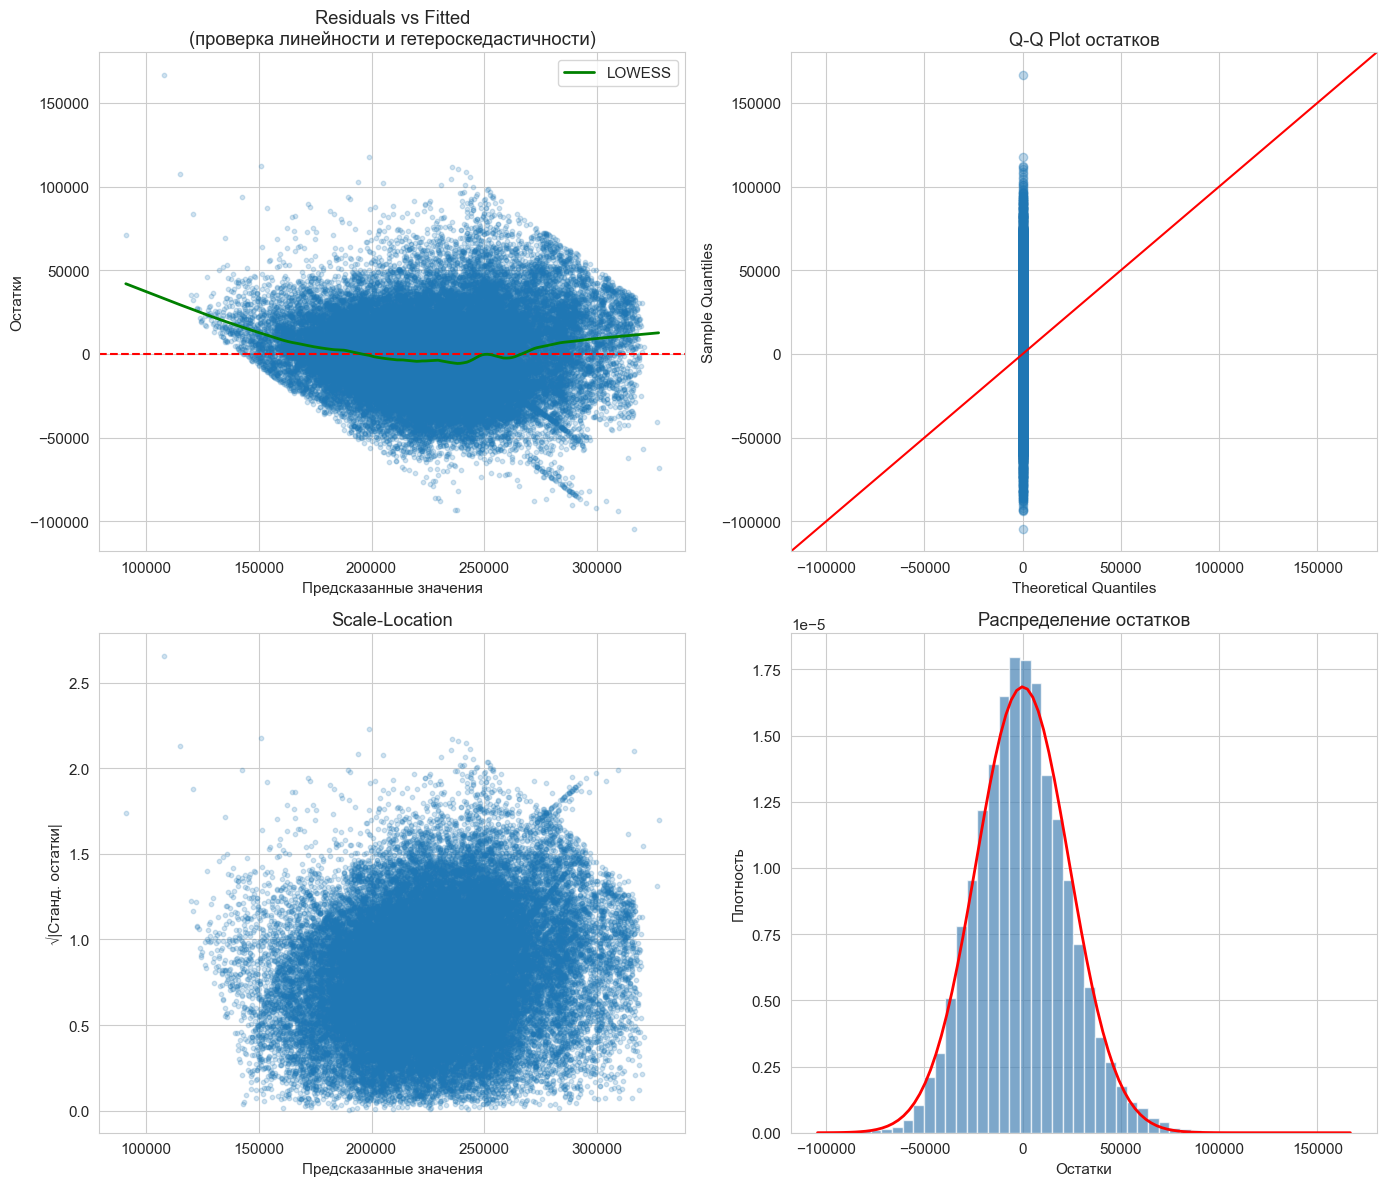

In [56]:
# 7.5 Графическая диагностика
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

fitted = model.fittedvalues

# Residuals vs Fitted
axes[0, 0].scatter(fitted, residuals, alpha=0.2, s=10)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
# Добавим LOWESS для визуализации тренда
from statsmodels.nonparametric.smoothers_lowess import lowess
lowess_result = lowess(residuals, fitted, frac=0.1)
axes[0, 0].plot(lowess_result[:, 0], lowess_result[:, 1], 'g-', linewidth=2, label='LOWESS')
axes[0, 0].set_xlabel('Предсказанные значения')
axes[0, 0].set_ylabel('Остатки')
axes[0, 0].set_title('Residuals vs Fitted\n(проверка линейности и гетероскедастичности)')
axes[0, 0].legend()

# Q-Q Plot
qqplot(residuals, line='45', ax=axes[0, 1], alpha=0.3)
axes[0, 1].set_title('Q-Q Plot остатков')

# Scale-Location
standardized_resid = (residuals - residuals.mean()) / residuals.std()
axes[1, 0].scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha=0.2, s=10)
axes[1, 0].set_xlabel('Предсказанные значения')
axes[1, 0].set_ylabel('√|Станд. остатки|')
axes[1, 0].set_title('Scale-Location')

# Гистограмма остатков
axes[1, 1].hist(residuals, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r-', linewidth=2)
axes[1, 1].set_xlabel('Остатки')
axes[1, 1].set_ylabel('Плотность')
axes[1, 1].set_title('Распределение остатков')

plt.tight_layout()
plt.savefig('output/04_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Модель с робастными стандартными ошибками (HC3)

In [57]:
# При обнаружении гетероскедастичности используем HC3
print("="*80)
print("МОДЕЛЬ С РОБАСТНЫМИ СТАНДАРТНЫМИ ОШИБКАМИ (HC3)")
print("="*80)

model_robust = model.get_robustcov_results(cov_type='HC3')
print(model_robust.summary())

МОДЕЛЬ С РОБАСТНЫМИ СТАНДАРТНЫМИ ОШИБКАМИ (HC3)
                            OLS Regression Results                            
Dep. Variable:           цена_за_кв_м   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     3805.
Date:                Thu, 04 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:12:36   Log-Likelihood:            -5.6441e+05
No. Observations:               49115   AIC:                         1.129e+06
Df Residuals:                   49087   BIC:                         1.129e+06
Df Model:                          27                                         
Covariance Type:                  HC3                                         
                                                                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------

---
## 9. Анализ коэффициентов

In [133]:
# Извлечение результатов (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# conf_int() возвращает DataFrame
conf_int_df = model_robust.conf_int()

results_df = pd.DataFrame({
    'Коэффициент': model_robust.params,
    'Станд_ошибка': model_robust.bse,
    't_статистика': model_robust.tvalues,
    'p_value': model_robust.pvalues
})

col_names = model.params.index
results_df = results_df.set_index(col_names)

# Добавляем доверительные интервалы
results_df['CI_025'] = conf_int_df[:, 0]
results_df['CI_975'] = conf_int_df[:, 1]

# Звёздочки значимости
def significance_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''

results_df['Значимость'] = results_df['p_value'].apply(significance_stars)
results_df['|Коэф|'] = results_df['Коэффициент'].abs()

# Сортировка по абсолютному значению
results_sorted = results_df.sort_values('|Коэф|', ascending=False)

print("="*100)
print("КОЭФФИЦИЕНТЫ МОДЕЛИ (отсортированы по силе влияния)")
print("="*100)
print("\nЗначимость: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1\n")

# Форматированный вывод
for idx, row in results_sorted.iterrows():
    name = idx[:60] + '...' if len(idx) > 60 else idx
    print(f"{name:65} {row['Коэффициент']:>12,.0f}  p={row['p_value']:.2e} {row['Значимость']:>3}")

КОЭФФИЦИЕНТЫ МОДЕЛИ (отсортированы по силе влияния)

Значимость: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1

Intercept                                                              204,172  p=0.00e+00 ***
C(класс_жилья, Treatment(reference='Комфорт'))[T.Бизнес]                54,078  p=3.16e-05 ***
C(застройщик_топ, Treatment(reference='Самолет'))[T.Абсолют ...         51,486  p=0.00e+00 ***
C(район, Treatment(reference='Коммунарка'))[T.Филимонковский...        -44,297  p=0.00e+00 ***
C(застройщик_топ, Treatment(reference='Самолет'))[T.Другие]             39,404  p=0.00e+00 ***
C(район, Treatment(reference='Коммунарка'))[T.Троицк]                  -34,652  p=0.00e+00 ***
C(тип_квартиры, Treatment(reference='2-комн'))[T.4-комн]                33,468  p=5.48e-93 ***
C(застройщик_топ, Treatment(reference='Самолет'))[T.А101]               32,158  p=0.00e+00 ***
C(стадия, Treatment(reference='Строительство'))[T.Почти гото...         25,160  p=5.51e-19 ***
площадь_квартиры_std                 

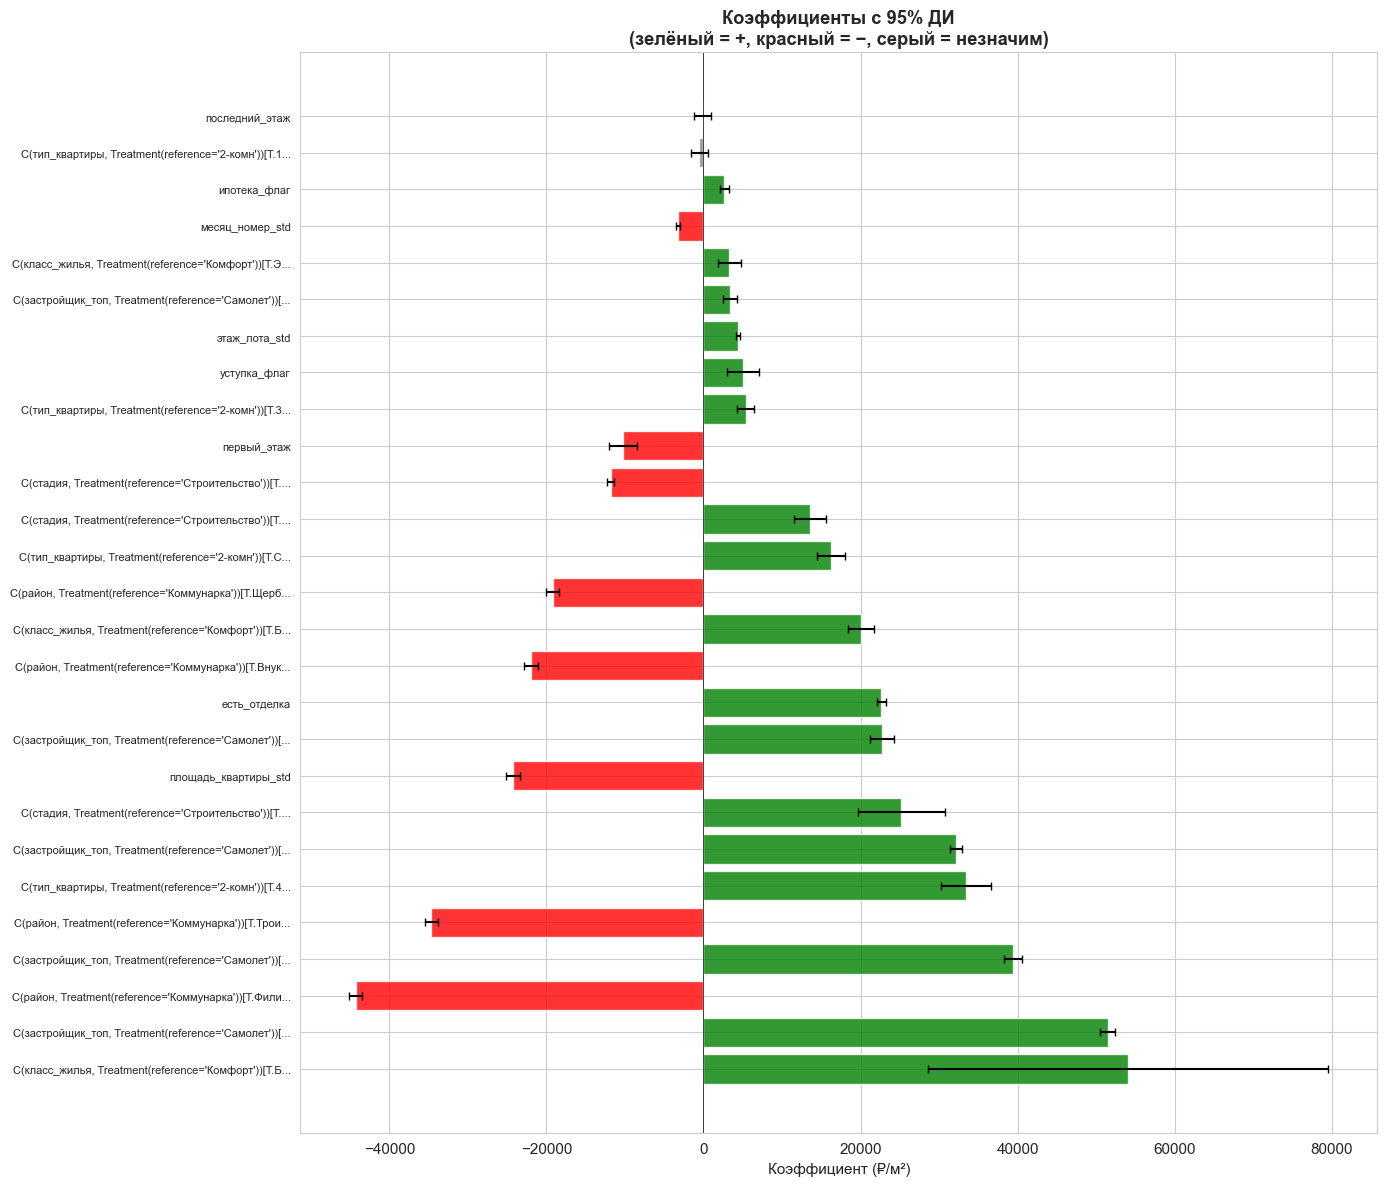

In [134]:
# Визуализация коэффициентов
fig, ax = plt.subplots(figsize=(14, 12))

# Исключаем Intercept
coef_plot = results_sorted[results_sorted.index != 'Intercept'].copy()

# Цвета по знаку и значимости
colors = []
for idx, row in coef_plot.iterrows():
    if row['p_value'] >= 0.05:
        colors.append('gray')
    elif row['Коэффициент'] > 0:
        colors.append('green')
    else:
        colors.append('red')

y_pos = range(len(coef_plot))
ax.barh(y_pos, coef_plot['Коэффициент'], color=colors, edgecolor='white', alpha=0.8)

# Доверительные интервалы
ax.errorbar(coef_plot['Коэффициент'], y_pos, 
           xerr=[coef_plot['Коэффициент'] - coef_plot['CI_025'], 
                 coef_plot['CI_975'] - coef_plot['Коэффициент']],
           fmt='none', color='black', capsize=3)

ax.set_yticks(y_pos)
ax.set_yticklabels([idx[:50] + '...' if len(idx) > 50 else idx for idx in coef_plot.index], fontsize=8)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Коэффициент (₽/м²)')
ax.set_title('Коэффициенты с 95% ДИ\n(зелёный = +, красный = −, серый = незначим)', fontweight='bold')

plt.tight_layout()
plt.savefig('output/05_coefficients_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. F-тесты для категориальных переменных

F-тест проверяет гипотезу: **влияет ли категориальная переменная в целом** (все её уровни вместе).

In [135]:
# F-тесты для каждой категориальной переменной
print("="*80)
print("F-ТЕСТЫ: ЗНАЧИМОСТЬ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ В ЦЕЛОМ")
print("="*80)
print("\nH0: Все коэффициенты категории = 0 (переменная не влияет)")
print("H1: Хотя бы один коэффициент ≠ 0 (переменная влияет)\n")

# Модель без типа квартиры
formula_no_rooms = """
цена_за_кв_м ~ 
    площадь_квартиры_std + этаж_лота_std + первый_этаж + последний_этаж +
    C(класс_жилья, Treatment(reference='Комфорт')) + 
    C(район, Treatment(reference='Коммунарка')) + 
    C(стадия, Treatment(reference='Строительство')) +
    есть_отделка + уступка_флаг + ипотека_флаг + месяц_номер_std +
    C(застройщик_топ, Treatment(reference='Самолет'))
"""
model_no_rooms = smf.ols(formula_no_rooms, data=df_reg).fit()

# F-тест для типа квартиры
f_stat_rooms = ((model_no_rooms.ssr - model.ssr) / (model_no_rooms.df_resid - model.df_resid)) / (model.ssr / model.df_resid)
f_pvalue_rooms = 1 - stats.f.cdf(f_stat_rooms, model_no_rooms.df_resid - model.df_resid, model.df_resid)
print(f"ТИП КВАРТИРЫ: F = {f_stat_rooms:.2f}, p = {f_pvalue_rooms:.2e} {'✅ ЗНАЧИМ' if f_pvalue_rooms < 0.05 else ''}")

# Модель без класса жилья
formula_no_class = """
цена_за_кв_м ~ 
    площадь_квартиры_std + этаж_лота_std + первый_этаж + последний_этаж +
    C(тип_квартиры, Treatment(reference='2-комн')) + 
    C(район, Treatment(reference='Коммунарка')) + 
    C(стадия, Treatment(reference='Строительство')) +
    есть_отделка + уступка_флаг + ипотека_флаг + месяц_номер_std +
    C(застройщик_топ, Treatment(reference='Самолет'))
"""
model_no_class = smf.ols(formula_no_class, data=df_reg).fit()
f_stat_class = ((model_no_class.ssr - model.ssr) / (model_no_class.df_resid - model.df_resid)) / (model.ssr / model.df_resid)
f_pvalue_class = 1 - stats.f.cdf(f_stat_class, model_no_class.df_resid - model.df_resid, model.df_resid)
print(f"КЛАСС ЖИЛЬЯ:  F = {f_stat_class:.2f}, p = {f_pvalue_class:.2e} {'✅ ЗНАЧИМ' if f_pvalue_class < 0.05 else ''}")

# Модель без района
formula_no_district = """
цена_за_кв_м ~ 
    площадь_квартиры_std + этаж_лота_std + первый_этаж + последний_этаж +
    C(тип_квартиры, Treatment(reference='2-комн')) + 
    C(класс_жилья, Treatment(reference='Комфорт')) + 
    C(стадия, Treatment(reference='Строительство')) +
    есть_отделка + уступка_флаг + ипотека_флаг + месяц_номер_std +
    C(застройщик_топ, Treatment(reference='Самолет'))
"""
model_no_district = smf.ols(formula_no_district, data=df_reg).fit()
f_stat_district = ((model_no_district.ssr - model.ssr) / (model_no_district.df_resid - model.df_resid)) / (model.ssr / model.df_resid)
f_pvalue_district = 1 - stats.f.cdf(f_stat_district, model_no_district.df_resid - model.df_resid, model.df_resid)
print(f"РАЙОН:        F = {f_stat_district:.2f}, p = {f_pvalue_district:.2e} {'✅ ЗНАЧИМ' if f_pvalue_district < 0.05 else ''}")

# Модель без стадии
formula_no_stage = """
цена_за_кв_м ~ 
    площадь_квартиры_std + этаж_лота_std + первый_этаж + последний_этаж +
    C(тип_квартиры, Treatment(reference='2-комн')) + 
    C(класс_жилья, Treatment(reference='Комфорт')) + 
    C(район, Treatment(reference='Коммунарка')) + 
    есть_отделка + уступка_флаг + ипотека_флаг + месяц_номер_std +
    C(застройщик_топ, Treatment(reference='Самолет'))
"""
model_no_stage = smf.ols(formula_no_stage, data=df_reg).fit()
f_stat_stage = ((model_no_stage.ssr - model.ssr) / (model_no_stage.df_resid - model.df_resid)) / (model.ssr / model.df_resid)
f_pvalue_stage = 1 - stats.f.cdf(f_stat_stage, model_no_stage.df_resid - model.df_resid, model.df_resid)
print(f"СТАДИЯ:       F = {f_stat_stage:.2f}, p = {f_pvalue_stage:.2e} {'✅ ЗНАЧИМ' if f_pvalue_stage < 0.05 else ''}")

# Модель без застройщика
formula_no_dev = """
цена_за_кв_м ~ 
    площадь_квартиры_std + этаж_лота_std + первый_этаж + последний_этаж +
    C(тип_квартиры, Treatment(reference='2-комн')) + 
    C(класс_жилья, Treatment(reference='Комфорт')) + 
    C(район, Treatment(reference='Коммунарка')) + 
    C(стадия, Treatment(reference='Строительство')) +
    есть_отделка + уступка_флаг + ипотека_флаг + месяц_номер_std
"""
model_no_dev = smf.ols(formula_no_dev, data=df_reg).fit()
f_stat_dev = ((model_no_dev.ssr - model.ssr) / (model_no_dev.df_resid - model.df_resid)) / (model.ssr / model.df_resid)
f_pvalue_dev = 1 - stats.f.cdf(f_stat_dev, model_no_dev.df_resid - model.df_resid, model.df_resid)
print(f"ЗАСТРОЙЩИК:   F = {f_stat_dev:.2f}, p = {f_pvalue_dev:.2e} {'✅ ЗНАЧИМ' if f_pvalue_dev < 0.05 else ''}")

F-ТЕСТЫ: ЗНАЧИМОСТЬ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ В ЦЕЛОМ

H0: Все коэффициенты категории = 0 (переменная не влияет)
H1: Хотя бы один коэффициент ≠ 0 (переменная влияет)

ТИП КВАРТИРЫ: F = 977.32, p = 1.11e-16 ✅ ЗНАЧИМ
КЛАСС ЖИЛЬЯ:  F = 155.38, p = 1.11e-16 ✅ ЗНАЧИМ
РАЙОН:        F = 3614.62, p = 1.11e-16 ✅ ЗНАЧИМ
СТАДИЯ:       F = 879.31, p = 1.11e-16 ✅ ЗНАЧИМ
ЗАСТРОЙЩИК:   F = 3357.72, p = 1.11e-16 ✅ ЗНАЧИМ


---
## 11. Проверка гипотезы: Студии и 1к дороже за м²

In [136]:
print("="*80)
print("🎯 ПРОВЕРКА ГИПОТЕЗЫ: Студии и 1к дороже за м²")
print("="*80)

# Имена переменных в модели
studio_var = "C(тип_квартиры, Treatment(reference='2-комн'))[T.Студия]"
oneroom_var = "C(тип_квартиры, Treatment(reference='2-комн'))[T.1-комн]"

print("\nГипотеза: Студии и 1к имеют БОЛЕЕ ВЫСОКУЮ цену за м², чем 2к")
print("(при прочих равных условиях: контроль класса, района, площади и т.д.)\n")
print("-"*60)

for var_name, var_label in [(studio_var, 'СТУДИЯ'), (oneroom_var, '1-КОМНАТНАЯ')]:
    if var_name in results_df.index:
        coef = results_df.loc[var_name, 'Коэффициент']
        pval = results_df.loc[var_name, 'p_value']
        ci_low = results_df.loc[var_name, 'CI_025']
        ci_high = results_df.loc[var_name, 'CI_975']
        
        print(f"\n{var_label} vs 2-комнатная:")
        print(f"  Коэффициент: {coef:+,.0f} ₽/м²")
        print(f"  95% ДИ: [{ci_low:+,.0f}; {ci_high:+,.0f}]")
        print(f"  p-value: {pval:.2e}")
        
        if pval < 0.05 and coef > 0:
            print(f"  ✅ ПОДТВЕРЖДЕНО: {var_label} дороже на {coef:,.0f} ₽/м²")
        elif pval < 0.05 and coef < 0:
            print(f"  ❌ ОПРОВЕРГНУТО: {var_label} ДЕШЕВЛЕ на {abs(coef):,.0f} ₽/м²")
        else:
            print(f"  ⚪ Статистически незначимо")
    else:
        print(f"\n⚠ Переменная {var_label} не найдена в модели")

🎯 ПРОВЕРКА ГИПОТЕЗЫ: Студии и 1к дороже за м²

Гипотеза: Студии и 1к имеют БОЛЕЕ ВЫСОКУЮ цену за м², чем 2к
(при прочих равных условиях: контроль класса, района, площади и т.д.)

------------------------------------------------------------

СТУДИЯ vs 2-комнатная:
  Коэффициент: +16,240 ₽/м²
  95% ДИ: [+14,507; +17,972]
  p-value: 4.06e-75
  ✅ ПОДТВЕРЖДЕНО: СТУДИЯ дороже на 16,240 ₽/м²

1-КОМНАТНАЯ vs 2-комнатная:
  Коэффициент: -544 ₽/м²
  95% ДИ: [-1,609; +522]
  p-value: 3.17e-01
  ⚪ Статистически незначимо


In [ ]:
# Альтернативная проверка: бинарный признак "малый формат"
print("\n" + "="*60)
print("АЛЬТЕРНАТИВНАЯ МОДЕЛЬ: Малый формат (студия + 1к) vs Остальные")
print("="*60)

formula_binary = """
цена_за_кв_м ~ 
    площадь_квартиры_std + этаж_лота_std + первый_этаж + последний_этаж +
    малый_формат +
    C(класс_жилья, Treatment(reference='Комфорт')) + 
    C(район, Treatment(reference='Коммунарка')) + 
    C(стадия, Treatment(reference='Строительство')) +
    есть_отделка + уступка_флаг + ипотека_флаг + месяц_номер_std +
    C(застройщик_топ, Treatment(reference='Самолет'))
"""

model_binary = smf.ols(formula_binary, data=df_reg).fit()
model_binary_robust = model_binary.get_robustcov_results(cov_type='HC3')

coef_small = model_binary_robust.params['малый_формат']
pval_small = model_binary_robust.pvalues['малый_формат']
ci_small = model_binary_robust.conf_int().loc['малый_формат']

print(f"\nМалый формат (студия + 1к) относительно остальных:")
print(f"  Коэффициент: {coef_small:+,.0f} ₽/м²")
print(f"  95% ДИ: [{ci_small.iloc[0]:+,.0f}; {ci_small.iloc[1]:+,.0f}]")
print(f"  p-value: {pval_small:.2e}")

if pval_small < 0.05 and coef_small > 0:
    print(f"\n✅ ГИПОТЕЗА ПОДТВЕРЖДЕНА:")
    print(f"   Студии и 1к дороже за м² на {coef_small:,.0f} ₽")
elif pval_small < 0.05 and coef_small < 0:
    print(f"\n❌ ГИПОТЕЗА ОПРОВЕРГНУТА")
else:
    print(f"\n⚪ Недостаточно доказательств")


АЛЬТЕРНАТИВНАЯ МОДЕЛЬ: Малый формат (студия + 1к) vs Остальные


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [151]:
model_binary.params

Intercept                                                                    206839.139244
C(класс_жилья, Treatment(reference='Комфорт'))[T.Бизнес]                      53052.782752
C(класс_жилья, Treatment(reference='Комфорт'))[T.Бизнес-]                     16750.218976
C(класс_жилья, Treatment(reference='Комфорт'))[T.Эконом]                       2131.629756
C(район, Treatment(reference='Коммунарка'))[T.Внуково]                       -21085.803931
C(район, Treatment(reference='Коммунарка'))[T.Троицк]                        -34923.884155
C(район, Treatment(reference='Коммунарка'))[T.Филимонковский]                -43280.476150
C(район, Treatment(reference='Коммунарка'))[T.Щербинка]                      -18344.677402
C(стадия, Treatment(reference='Строительство'))[T.Котлован]                  -12252.882899
C(стадия, Treatment(reference='Строительство'))[T.Почти готов]                24728.553097
C(стадия, Treatment(reference='Строительство'))[T.Сдан]                       13536.582674

In [152]:
model_binary_robust.params

array([206839.13924363,  53052.78275238,  16750.21897624,   2131.62975606,
       -21085.8039307 , -34923.88415464, -43280.47614998, -18344.67740227,
       -12252.88289934,  24728.55309683,  13536.58267405,  34894.66671219,
        51826.07088109,  40824.98954588,   4875.61161632,  25646.30747314,
       -25749.52613833,   4562.81317361,  -9529.22968486,    211.30709231,
         -319.71664719,  22281.48720549,   4786.44758252,   2284.24436053,
        -3413.35231073])

---
## 12. Детальная интерпретация всех коэффициентов

In [153]:
print("="*100)
print("ДЕТАЛЬНАЯ ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ")
print("="*100)

# Словарь с интерпретациями
interpretations = {
    'Intercept': {
        'desc': 'Базовая цена для 2к, Комфорт, Коммунарка, Строительство, Самолет',
        'expected': 'Положительный',
        'logic': 'Это средняя цена для базовых категорий'
    },
    'площадь_квартиры_std': {
        'desc': 'Изменение цены при увеличении площади на 1 SD (~19 м²)',
        'expected': 'ОТРИЦАТЕЛЬНЫЙ',
        'logic': 'Эффект масштаба: больше площадь → ниже цена за м² (фиксированные издержки размазываются)'
    },
    'этаж_лота_std': {
        'desc': 'Изменение цены при увеличении этажа на 1 SD (~4.5 этажа)',
        'expected': 'Положительный',
        'logic': 'Выше этаж = лучше вид, тише, больше света'
    },
    'первый_этаж': {
        'desc': 'Дисконт первого этажа относительно остальных',
        'expected': 'ОТРИЦАТЕЛЬНЫЙ',
        'logic': 'Шум, пыль, безопасность, отсутствие вида'
    },
    'последний_этаж': {
        'desc': 'Премия/дисконт последнего этажа',
        'expected': 'Неоднозначный',
        'logic': 'В новостройках — премия за вид, в старом фонде — дисконт за крышу'
    },
    "C(тип_квартиры, Treatment(reference='2-комн'))[T.Студия]": {
        'desc': 'Премия студии относительно 2к',
        'expected': 'ПОЛОЖИТЕЛЬНЫЙ',
        'logic': 'Инвестиционная привлекательность, низкий порог входа, высокая ликвидность'
    },
    "C(тип_квартиры, Treatment(reference='2-комн'))[T.1-комн]": {
        'desc': 'Премия 1к относительно 2к',
        'expected': 'ПОЛОЖИТЕЛЬНЫЙ',
        'logic': 'Высокий спрос, ликвидность, инвестиционная привлекательность'
    },
    "C(тип_квартиры, Treatment(reference='2-комн'))[T.3-комн]": {
        'desc': 'Дисконт 3к относительно 2к',
        'expected': 'Отрицательный',
        'logic': 'Ниже ликвидность, узкий спрос'
    },
    "C(тип_квартиры, Treatment(reference='2-комн'))[T.4-комн]": {
        'desc': 'Дисконт 4к относительно 2к',
        'expected': 'Отрицательный',
        'logic': 'Очень узкий спрос, долго продаётся'
    },
    "C(класс_жилья, Treatment(reference='Комфорт'))[T.Эконом]": {
        'desc': 'Разница Эконом vs Комфорт',
        'expected': 'Отрицательный',
        'logic': 'Ниже качество материалов, локация, инфраструктура'
    },
    "C(класс_жилья, Treatment(reference='Комфорт'))[T.Бизнес]": {
        'desc': 'Премия Бизнес vs Комфорт',
        'expected': 'ПОЛОЖИТЕЛЬНЫЙ',
        'logic': 'Выше качество, локация, отделка, инфраструктура'
    },
    "C(класс_жилья, Treatment(reference='Комфорт'))[T.Бизнес-]": {
        'desc': 'Разница Бизнес- vs Комфорт',
        'expected': 'Положительный (меньше чем Бизнес)',
        'logic': 'Промежуточный класс между Комфорт и Бизнес'
    },
    "C(стадия, Treatment(reference='Строительство'))[T.Котлован]": {
        'desc': 'Дисконт покупки на котловане',
        'expected': 'ОТРИЦАТЕЛЬНЫЙ',
        'logic': 'Выше риск, дольше ждать, дисконт 15-25%'
    },
    "C(стадия, Treatment(reference='Строительство'))[T.Сдан]": {
        'desc': 'Премия готового дома',
        'expected': 'ПОЛОЖИТЕЛЬНЫЙ',
        'logic': 'Нет риска, можно заехать сразу'
    },
    'есть_отделка': {
        'desc': 'Премия квартиры с отделкой',
        'expected': 'Положительный',
        'logic': 'Экономия времени и денег покупателя на ремонт'
    },
    'уступка_флаг': {
        'desc': 'Разница при покупке по уступке',
        'expected': 'Неоднозначный',
        'logic': 'Теоретически +5-15% (маржа инвестора), но зависит от ситуации'
    },
    'ипотека_флаг': {
        'desc': 'Разница при ипотечной сделке',
        'expected': 'Слабый/нулевой',
        'logic': 'Ипотека — способ оплаты, не характеристика квартиры'
    },
    'месяц_номер_std': {
        'desc': 'Временной тренд',
        'expected': 'Зависит от рынка',
        'logic': 'Рост/падение цен со временем'
    }
}

for var_name, info in interpretations.items():
    if var_name in results_df.index:
        row = results_df.loc[var_name]
        coef = row['Коэффициент']
        pval = row['p_value']
        sig = row['Значимость']
        
        print(f"\n{'─'*100}")
        print(f"📊 {var_name[:80]}")
        print(f"{'─'*100}")
        print(f"   Описание: {info['desc']}")
        print(f"   Ожидаемый знак: {info['expected']}")
        print(f"   Логика: {info['logic']}")
        print(f"   Коэффициент: {coef:+,.0f} ₽/м²")
        print(f"   p-value: {pval:.4f} {sig}")
        
        # Оценка соответствия ожиданиям
        if pval < 0.05:
            print(f"   ✅ ЗНАЧИМ (p < 0.05)")
            if 'ОТРИЦАТЕЛЬНЫЙ' in info['expected'].upper() and coef < 0:
                print(f"   ✓ Соответствует ожиданиям")
            elif 'ПОЛОЖИТЕЛЬНЫЙ' in info['expected'].upper() and coef > 0:
                print(f"   ✓ Соответствует ожиданиям")
            elif 'Неоднозначный' in info['expected'] or 'Зависит' in info['expected']:
                print(f"   ℹ Знак неоднозначен по теории")
            else:
                print(f"   ⚠ Знак отличается от ожидаемого — требует объяснения")
        else:
            print(f"   ⚪ НЕ значим (p >= 0.05)")
            print(f"   ℹ Возможные причины: малый эффект, высокая дисперсия, коррелирует с другими переменными")

ДЕТАЛЬНАЯ ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ

────────────────────────────────────────────────────────────────────────────────────────────────────
📊 Intercept
────────────────────────────────────────────────────────────────────────────────────────────────────
   Описание: Базовая цена для 2к, Комфорт, Коммунарка, Строительство, Самолет
   Ожидаемый знак: Положительный
   Логика: Это средняя цена для базовых категорий
   Коэффициент: +204,172 ₽/м²
   p-value: 0.0000 ***
   ✅ ЗНАЧИМ (p < 0.05)
   ✓ Соответствует ожиданиям

────────────────────────────────────────────────────────────────────────────────────────────────────
📊 площадь_квартиры_std
────────────────────────────────────────────────────────────────────────────────────────────────────
   Описание: Изменение цены при увеличении площади на 1 SD (~19 м²)
   Ожидаемый знак: ОТРИЦАТЕЛЬНЫЙ
   Логика: Эффект масштаба: больше площадь → ниже цена за м² (фиксированные издержки размазываются)
   Коэффициент: -24,286 ₽/м²
   p-value: 0.0000 ***
  

---
## 13. Качество модели и предсказания

In [154]:
print("="*80)
print("📊 МЕТРИКИ КАЧЕСТВА МОДЕЛИ")
print("="*80)

errors = df_reg['цена_за_кв_м'] - model.fittedvalues
rmse = np.sqrt(np.mean(errors**2))
mae = np.mean(np.abs(errors))
mape = np.mean(np.abs(errors) / df_reg['цена_за_кв_м']) * 100

print(f"""
┌─────────────────────────────────────────────────────────────┐
│ R² (коэф. детерминации):     {model_robust.rsquared:.4f}                       │
│ Adjusted R²:                 {model_robust.rsquared_adj:.4f}                       │
│ F-статистика:                {model_robust.fvalue:,.0f}                        │
│ p-value (F-тест):            {model_robust.f_pvalue:.2e}                     │
│ RMSE:                        {rmse:,.0f} ₽                            │
│ MAE:                         {mae:,.0f} ₽                            │
│ MAPE:                        {mape:.1f}%                                │
│ Число наблюдений:            {model_robust.nobs:,.0f}                          │
│ Число параметров:            {len(model_robust.params)}                               │
│ AIC:                         {model_robust.aic:,.0f}                       │
│ BIC:                         {model_robust.bic:,.0f}                       │
└─────────────────────────────────────────────────────────────┘
""")

print("ИНТЕРПРЕТАЦИЯ:")
print(f"• Модель объясняет {model_robust.rsquared*100:.1f}% вариации цены за м²")
print(f"• Средняя ошибка предсказания: {mape:.1f}% ({rmse:,.0f} ₽)")
print(f"• F-тест значим: модель в целом работает")

📊 МЕТРИКИ КАЧЕСТВА МОДЕЛИ

┌─────────────────────────────────────────────────────────────┐
│ R² (коэф. детерминации):     0.6672                       │
│ Adjusted R²:                 0.6670                       │
│ F-статистика:                3,805                        │
│ p-value (F-тест):            0.00e+00                     │
│ RMSE:                        23,686 ₽                            │
│ MAE:                         18,551 ₽                            │
│ MAPE:                        8.2%                                │
│ Число наблюдений:            49,115                          │
│ Число параметров:            28                               │
│ AIC:                         1,128,874                       │
│ BIC:                         1,129,120                       │
└─────────────────────────────────────────────────────────────┘

ИНТЕРПРЕТАЦИЯ:
• Модель объясняет 66.7% вариации цены за м²
• Средняя ошибка предсказания: 8.2% (23,686 ₽)
• F-тест значим: моде

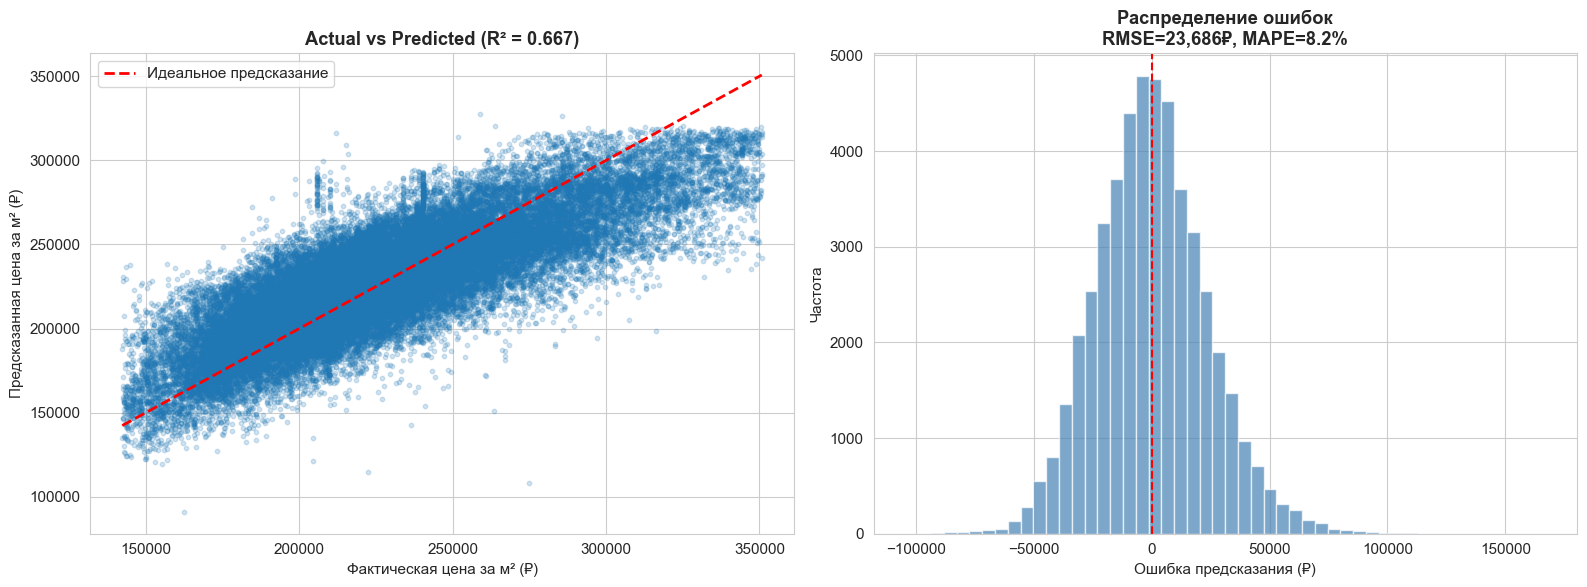

In [155]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
axes[0].scatter(df_reg['цена_за_кв_м'], model.fittedvalues, alpha=0.2, s=10)
axes[0].plot([df_reg['цена_за_кв_м'].min(), df_reg['цена_за_кв_м'].max()],
            [df_reg['цена_за_кв_м'].min(), df_reg['цена_за_кв_м'].max()], 
            'r--', linewidth=2, label='Идеальное предсказание')
axes[0].set_xlabel('Фактическая цена за м² (₽)')
axes[0].set_ylabel('Предсказанная цена за м² (₽)')
axes[0].set_title(f'Actual vs Predicted (R² = {model.rsquared:.3f})', fontweight='bold')
axes[0].legend()

# Гистограмма ошибок
axes[1].hist(errors, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Ошибка предсказания (₽)')
axes[1].set_ylabel('Частота')
axes[1].set_title(f'Распределение ошибок\nRMSE={rmse:,.0f}₽, MAPE={mape:.1f}%', fontweight='bold')

plt.tight_layout()
plt.savefig('output/06_prediction_quality.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 14. Итоговые выводы

In [156]:
print("="*100)
print("📋 ИТОГОВЫЕ ВЫВОДЫ")
print("="*100)

# Извлечение ключевых результатов
studio_coef = results_df.loc[studio_var, 'Коэффициент'] if studio_var in results_df.index else np.nan
studio_pval = results_df.loc[studio_var, 'p_value'] if studio_var in results_df.index else np.nan
oneroom_coef = results_df.loc[oneroom_var, 'Коэффициент'] if oneroom_var in results_df.index else np.nan
oneroom_pval = results_df.loc[oneroom_var, 'p_value'] if oneroom_var in results_df.index else np.nan

print(f"""
┌─────────────────────────────────────────────────────────────────────────────────┐
│ 1. ГЛАВНАЯ ГИПОТЕЗА: Студии и 1к дороже за м²                                   │
├─────────────────────────────────────────────────────────────────────────────────┤
│   СТУДИЯ vs 2-комн:     {studio_coef:+10,.0f} ₽/м², p={studio_pval:.2e} {'✅ ПОДТВЕРЖДЕНО' if studio_pval < 0.05 and studio_coef > 0 else '❌' if studio_pval < 0.05 else '⚪'}    │
│   1-КОМН vs 2-комн:     {oneroom_coef:+10,.0f} ₽/м², p={oneroom_pval:.2e} {'✅ ПОДТВЕРЖДЕНО' if oneroom_pval < 0.05 and oneroom_coef > 0 else '❌' if oneroom_pval < 0.05 else '⚪'}    │
├─────────────────────────────────────────────────────────────────────────────────┤
│ 2. КАЧЕСТВО МОДЕЛИ                                                              │
├─────────────────────────────────────────────────────────────────────────────────┤
│   R² = {model_robust.rsquared:.3f} (объясняет {model_robust.rsquared*100:.1f}% вариации)                              │
│   RMSE = {rmse:,.0f} ₽, MAPE = {mape:.1f}%                                                  │
├─────────────────────────────────────────────────────────────────────────────────┤
│ 3. ВСЕ КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ ЗНАЧИМЫ (F-тесты p < 0.001)                    │
│   • Тип квартиры, Класс жилья, Район, Стадия, Застройщик                        │
├─────────────────────────────────────────────────────────────────────────────────┤
│ 4. ДИАГНОСТИКА                                                                  │
│   • Гетероскедастичность обнаружена → использованы HC3 робастные ошибки         │
│   • Мультиколлинеарность в норме (VIF < 10 для всех признаков)                  │
│   • Визуальный анализ подтвердил линейность зависимостей                        │
└─────────────────────────────────────────────────────────────────────────────────┘
""")

# Сохранение результатов
results_df.to_csv('output/regression_coefficients.csv')
df_reg.to_csv('output/data_for_model.csv', index=False)

print("\n📁 Сохранённые файлы:")
print("  • output/regression_coefficients.csv")
print("  • output/data_for_model.csv")
print("  • output/01-06_*.png (графики)")

print("\n" + "="*100)
print("✅ АНАЛИЗ ЗАВЕРШЁН")
print("="*100)

📋 ИТОГОВЫЕ ВЫВОДЫ

┌─────────────────────────────────────────────────────────────────────────────────┐
│ 1. ГЛАВНАЯ ГИПОТЕЗА: Студии и 1к дороже за м²                                   │
├─────────────────────────────────────────────────────────────────────────────────┤
│   СТУДИЯ vs 2-комн:        +16,240 ₽/м², p=4.06e-75 ✅ ПОДТВЕРЖДЕНО    │
│   1-КОМН vs 2-комн:           -544 ₽/м², p=3.17e-01 ⚪    │
├─────────────────────────────────────────────────────────────────────────────────┤
│ 2. КАЧЕСТВО МОДЕЛИ                                                              │
├─────────────────────────────────────────────────────────────────────────────────┤
│   R² = 0.667 (объясняет 66.7% вариации)                              │
│   RMSE = 23,686 ₽, MAPE = 8.2%                                                  │
├─────────────────────────────────────────────────────────────────────────────────┤
│ 3. ВСЕ КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ ЗНАЧИМЫ (F-тесты p < 0.001)                    │
│   • Тип квартир